<a href="https://colab.research.google.com/github/praptiii/wifi_indoor_positioning_system/blob/main/ips.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.1 MB/s eta 0:00:00


In [ ]:
import io
import pandas as pd
import numpy as np
import random
import tensorflow as tf
from scipy.spatial.distance import cdist
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_val_score
from tensorflow.keras.optimizers import Adam
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from google.colab import files
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


In [ ]:
uploaded= files.upload()

Saving training.csv to training.csv


In [ ]:
train_data= pd.read_csv('training.csv')
train_data.head()

,X,Y,M1[ea:fb:1c:47:b3:bf],M2 [c8:84:8c:3b:81:a8],M3[c8:84:8c:bb:49:0c],M4[c8:84:8c:7a:f5:fd],M5[c8:84:8c:7a:f5:fc],M6 ( c8:84:8c:bb:88:68),M7 ([c8:84:8c:3b:43:dc),M8 [c8:84:8c:7a:88:6c],...,M41 [c8:84:8c:bb:7e:ec],M42[c8:84:8c:bb:7f:68],M43[1c:3a:60:43:1c:fc],M44[c8:84:8c:3b:7e:c8],M45[c8:84:8c:3b:48:4c],M46 [c8:84:8c:3b:3c:9c],M47 [c8:84:8c:3b:7f:08],M48[c8:84:8c:7b:7e:9c],M49[c8:84:8c:7b:81:ac],M50[c8:84:8c:7b:7f:08]
0,11,9,-73,-85,-63,-81,-75,-1000,-1000,-1000,...,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000
1,10,8,-68,-1000,-67,-83,-82,-1000,-82,-1000,...,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000
2,9,8,-74,-1000,-1000,-84,-84,-1000,-69,-1000,...,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000
3,10,10,-71,-1000,-1000,-81,-82,-1000,-76,-1000,...,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000
4,8,10,-83,-1000,-1000,-1000,-1000,-52,-69,-1000,...,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000


In [ ]:
uploaded= files.upload()

Saving testing.csv to testing.csv


In [ ]:
test_data= pd.read_csv('testing.csv')
test_data.head()

,X,Y,M1[ea:fb:1c:47:b3:bf],M2 [c8:84:8c:3b:81:a8],M3[c8:84:8c:bb:49:0c],M4[c8:84:8c:7a:f5:fd],M5[c8:84:8c:7a:f5:fc],M6 ( c8:84:8c:bb:88:68),M7 ([c8:84:8c:3b:43:dc),M8 [c8:84:8c:7a:88:6c],...,M41 [c8:84:8c:bb:7e:ec],M42[c8:84:8c:bb:7f:68],M43[1c:3a:60:43:1c:fc],M44[c8:84:8c:3b:7e:c8],M45[c8:84:8c:3b:48:4c],M46 [c8:84:8c:3b:3c:9c],M47 [c8:84:8c:3b:7f:08],M48[c8:84:8c:7b:7e:9c],M49[c8:84:8c:7b:81:ac],M50[c8:84:8c:7b:7f:08]
0,3,13,-67,-1000,-1000,-1000,-1000,-1000,-1000,-1000,...,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-71,-1000,-1000
1,4,15,-62,-83,-1000,-1000,-1000,-1000,-1000,-1000,...,-1000,-1000,-1000,-1000,-1000,-1000,-67,-1000,-1000,-1000
2,5,11,-1000,-1000,-1000,-1000,-68,-1000,-1000,-77,...,-1000,-69,-1000,-1000,-73,-1000,-1000,-1000,-1000,-1000
3,6,10,-75,-1000,-81,-1000,-1000,-65,-1000,-1000,...,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000
4,7,12,-1000,-87,-1000,-75,-1000,-1000,-1000,-1000,...,-1000,-1000,-79,-1000,-1000,-56,-1000,-1000,-1000,-83


In [ ]:
train_data.columns

Index(['X', 'Y', 'M1[ea:fb:1c:47:b3:bf]', 'M2 [c8:84:8c:3b:81:a8]',
       'M3[c8:84:8c:bb:49:0c]', 'M4[c8:84:8c:7a:f5:fd]',
       'M5[c8:84:8c:7a:f5:fc]', 'M6 ( c8:84:8c:bb:88:68)',
       'M7 ([c8:84:8c:3b:43:dc)', 'M8 [c8:84:8c:7a:88:6c]',
       'M9[c8:84:8c:bb:88:28]', 'M10[c8:84:8c:3b:39:68]',
       'M11[c8:84:8c:bb:7d:a8]', 'M12[c8:84:8c:bb:47:88]',
       'M13[c8:84:8c:7a:89:08] ', 'M14[c8:84:8c:3b:88:78]',
       'M15[c8:84:8c:7b:7e:fc] ', 'M16 [c8:84:8c:7a:43:dc]',
       'M17[c8:84:8c:bb:7e:98]', 'M18[c8:84:8c:bb:7f:98]',
       'M19[c8:84:8c:7a:44:0c]', 'M20 [c8:84:8c:3b:88:38]',
       'M21[c8:84:8c:7b:7f:1c] ', 'M22[c8:84:8c:7b:48:4c]',
       'M23[c8:84:8c:7a:88:a8]', 'M24[1c:3a:60:03:1c:fc]',
       'M25[c8:84:8c:7b:44:0c]', 'M26[[c8:84:8c:7b:7f:38]',
       'M27[04:92:26:80:D5:48]', ' M28[c8:84:8c:7b:6e:48]',
       'M29 [c8:84:8c:7b:3c:9c] ', 'M30[c8:84:8c:bb:7f:0c] ',
       'M31 [c8:84:8c:bb:7f:9c] ', 'M32[c8:84:8c:bb:48:4c]',
       'M33 [c8:84:8c:3b:34:7c]', 'M3

In [ ]:
print(train_data.head())

    X   Y  M1[ea:fb:1c:47:b3:bf]  M2 [c8:84:8c:3b:81:a8]  \
0  11   9                    -73                     -85   
1  10   8                    -68                   -1000   
2   9   8                    -74                   -1000   
3  10  10                    -71                   -1000   
4   8  10                    -83                   -1000   

   M3[c8:84:8c:bb:49:0c]  M4[c8:84:8c:7a:f5:fd]  M5[c8:84:8c:7a:f5:fc]  \
0                    -63                    -81                    -75   
1                    -67                    -83                    -82   
2                  -1000                    -84                    -84   
3                  -1000                    -81                    -82   
4                  -1000                  -1000                  -1000   

   M6 ( c8:84:8c:bb:88:68)  M7 ([c8:84:8c:3b:43:dc)  M8 [c8:84:8c:7a:88:6c]  \
0                    -1000                    -1000                   -1000   
1                    -1000          

In [ ]:
# Separate features (RSS values) and target variables (X and Y coordinates)
X = train_data.drop(['X', 'Y'], axis=1)
y = train_data[['X', 'Y']]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Scale the input features
scaler_x = MinMaxScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

y_min = np.min(y_train.to_numpy(), axis=0)
y_max = np.max(y_train.to_numpy(), axis=0)

y_train_scaled = (y_train.to_numpy() - y_min) / (y_max - y_min)
y_test_scaled = (y_test.to_numpy() - y_min) / (y_max - y_min)

# Reshape the input features for compatibility with Conv1D layer
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

In [ ]:
# Train the KNN Regressor model
k = 4  # Number of neighbors
model = KNeighborsRegressor(n_neighbors=k)
model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=4)

In [ ]:
# Evaluate the model
y_pred_knn = model.predict(X_test)
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mape_knn = np.mean(np.abs((y_test.to_numpy().ravel() - y_pred_knn.ravel()) / y_test.to_numpy().ravel())) * 100
accuracy_knn=100-mape_knn
print('Mean Squared Error:', mse_knn)
print('Mean Absolute Error:', mae_knn)
print(f'Accuracy:{accuracy_knn:.2f}%')

Mean Squared Error: 1.64375
Mean Absolute Error: 0.9249999999999999
Accuracy:90.17%


In [ ]:
# Train the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test.to_numpy().ravel() - y_pred_rf.ravel()) / y_test.to_numpy().ravel())) * 100
accuracy_rf=100-mape_rf
print('Mean Squared Error:', mse_rf)
print('Mean Absolute Error:', mae_rf)
print(f'Accuracy:{accuracy_rf:.2f}%')

Mean Squared Error: 1.7108100000000008
Mean Absolute Error: 0.9810000000000001
Accuracy:89.75%


In [ ]:
# Initialize Gradient Boosting Regressor model
gb_model = GradientBoostingRegressor(random_state=10)

# Wrap the model with MultiOutputRegressor
multioutput_gb = MultiOutputRegressor(gb_model)

# Fit the model
multioutput_gb.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = multioutput_gb.predict(X_test)

# Calculate Mean Squared Error and Mean Absolute Error
mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mape_gb = np.mean(np.abs((y_test.to_numpy().ravel() - y_pred_gb.ravel()) / y_test.to_numpy().ravel())) * 100
accuracy_gb=100-mape_gb
print("Gradient Boosting - Mean Squared Error (MSE):", mse_gb)
print("Gradient Boosting - Mean Absolute Error (MAE):", mae_gb)
print(f'Accuracy:{accuracy_gb:.2f}%')

Gradient Boosting - Mean Squared Error (MSE): 1.9244312336880272
Gradient Boosting - Mean Absolute Error (MAE): 1.003722337726731
Accuracy:87.95%


In [ ]:
# Train the SVM model for X coordinate
svm_model_x = SVR(kernel='rbf')
svm_model_x.fit(X_train_scaled, y_train['X'])

# Train the SVM model for Y coordinate
svm_model_y = SVR(kernel='rbf')
svm_model_y.fit(X_train_scaled, y_train['Y'])

# Predict the X coordinates
y_pred_x = svm_model_x.predict(X_test_scaled)

# Predict the Y coordinates
y_pred_y = svm_model_y.predict(X_test_scaled)

# Combine X and Y coordinates
y_pred_combined = pd.DataFrame({'X': y_pred_x, 'Y': y_pred_y})

# Compute the mean squared error for both coordinates combined
mse_svm = mean_squared_error(y_test, y_pred_combined)
print('Mean Squared Error (Combined):', mse_svm)

# Compute the mean absolute error for both coordinates combined
mae_svm = mean_absolute_error(y_test, y_pred_combined)
print('Mean Absolute Error (Combined):', mae_svm)

mape = np.mean(np.abs((y_test.to_numpy().ravel() - y_pred_combined.to_numpy().ravel()) / y_test.to_numpy().ravel())) * 100
accuracy_svm=100-mape
print(f'Accuracy:{accuracy_svm:.2f}%')

Mean Squared Error (Combined): 8.617647429163785
Mean Absolute Error (Combined): 2.0433648230540147
Accuracy:76.91%


In [ ]:
ff_model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(2, activation='tanh')
])

# Use a Lower Learning Rate for Stability
ff_model.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error')

# Train the Model with More Epochs and Smaller Batch Size
ff_model.fit(X_train_scaled, y_train_scaled, epochs=100, batch_size=8, verbose=1)

# Make Predictions
y_pred_ff_scaled = ff_model.predict(X_test_scaled)

# Rescale Predictions Back to Original Range
y_pred_ff = y_pred_ff_scaled * (y_max - y_min) + y_min


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.3100
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2774
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2485
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2228
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2006
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1843 
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1658
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1522
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1308
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1221
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1121
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1024
Epoch 13/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1004
Epoch 14/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0937
Epoch 15/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0867 
Epoch 16/100
3/3 ━━━━━━━━━━━━

In [ ]:
# Evaluate the Model
mse_ff = mean_squared_error(y_test.to_numpy(), y_pred_ff)
mae_ff = mean_absolute_error(y_test.to_numpy(), y_pred_ff)

# Fix division issues in MAPE calculation
y_test_safe = np.where(y_test.to_numpy() == 0, 1e-10, y_test.to_numpy())
y_pred_safe = np.where(y_pred_ff == 0, 1e-10, y_pred_ff)

mape_ff = np.mean(np.abs((y_test_safe.ravel() - y_pred_safe.ravel()) / y_test_safe.ravel())) * 100
accuracy_ff = max(0, 100 - mape_ff)  # Ensuring accuracy is not negative

# Print Results
print("Neural Network - Mean Squared Error (MSE):", mse_ff)
print("Neural Network - Mean Absolute Error (MAE):", mae_ff)
print(f"Accuracy: {accuracy_ff:.2f}%")

Neural Network - Mean Squared Error (MSE): 15.259996145799324
Neural Network - Mean Absolute Error (MAE): 2.2800378359854223
Accuracy: 71.36%


In [ ]:
#Define the CNN model
model = Sequential([
    Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)),
    MaxPooling1D(pool_size=2), #reduces dimentionality
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),  #Prevent Overfitting
    Dense(64, activation='relu'),
    Dense(2, activation='sigmoid')  #output range [0,1]
])
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.00001), loss='mean_squared_error')

# Train the model
model.fit(X_train_reshaped, y_train_scaled, epochs=100, batch_size=8, verbose=1)

y_pred_cnn_scaled = model.predict(X_test_reshaped)
y_pred_cnn = y_pred_cnn_scaled * (y_max - y_min) + y_min

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1143
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1154
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1145
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1145
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1141
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1138
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1136
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1150
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1139 
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1140
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1145
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1138
Epoch 13/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1145 
Epoch 14/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1137
Epoch 15/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1127
Epoch 16/100
3/3 ━━━━━━━━━━━━

In [ ]:
# Evaluate Model
mse_cnn = mean_squared_error(y_test.to_numpy(), y_pred_cnn)
mae_cnn = mean_absolute_error(y_test.to_numpy(), y_pred_cnn)

# Fix MAPE Calculation (Avoid Division by Zero)
y_test_safe = np.where(y_test.to_numpy() == 0, 1e-10, y_test.to_numpy())
y_pred_safe = np.where(y_pred_cnn == 0, 1e-10, y_pred_cnn)

mape_cnn = np.mean(np.abs((y_test_safe.ravel() - y_pred_safe.ravel()) / y_test_safe.ravel())) * 100
accuracy_cnn = max(0, 100 - mape_cnn)  # Ensure accuracy is not negative

# Print Final Results
print("Neural Network - Mean Squared Error (MSE):", mse_cnn)
print("Neural Network - Mean Absolute Error (MAE):", mae_cnn)
print(f"Accuracy: {accuracy_cnn:.2f}%")

Neural Network - Mean Squared Error (MSE): 20.749840128809247
Neural Network - Mean Absolute Error (MAE): 3.817008846998197
Accuracy: 51.47%


In [ ]:
# AWDKNN Class with Gaussian Weighting
class AWDKNN(BaseEstimator, RegressorMixin):
    def __init__(self, k=4, sigma=1.0):
        self.k = k
        self.sigma = sigma
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def gaussian_weights(self, distances):
        return np.exp(- (distances ** 2) / (2 * self.sigma ** 2))
    def predict(self, X):
      X = np.array(X)
      predictions = []

      for x in X:
          distances = np.linalg.norm(self.X_train - x, axis=1)
          indices = np.argsort(distances)[:self.k]

        # Compute Gaussian weights
          weights = self.gaussian_weights(distances[indices])

        # Ensure weights sum is not zero
          weights_sum = np.sum(weights)
          if weights_sum == 0:
            weights = np.ones_like(weights)  # Assign equal weight if all are zero
            weights_sum = np.sum(weights)

          weights /= weights_sum  # Normalize weights

          prediction = np.dot(weights, self.y_train[indices])
          predictions.append(prediction)

      return np.array(predictions)


In [ ]:
# Define the search space for Bayesian Optimization
search_space = {
    'k': Integer(3, 20),         # Number of neighbors (3 to 20)
    'sigma': Real(0.1, 2.0)       # Gaussian kernel smoothing (0.1 to 2.0)
}

# Bayesian Optimization using BayesSearchCV
optimizer = BayesSearchCV(
    AWDKNN(),
    search_space,
    n_iter=30,          # Number of optimization iterations
    cv=5,               # 5-fold Cross-Validation
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

# Run the optimization
optimizer.fit(X_train_scaled, y_train)

# Get the best parameters
best_k = optimizer.best_params_['k']
best_sigma = optimizer.best_params_['sigma']

print(f"Best k: {best_k}")
print(f"Best sigma: {best_sigma}")


Best k: 3
Best sigma: 0.4809072764350847


In [ ]:
# Train AWDKNN with the best hyperparameters
best_awdknn = AWDKNN(k=best_k, sigma=best_sigma)
best_awdknn.fit(X_train_scaled, y_train)

# Make predictions
y_pred_awdk = best_awdknn.predict(X_test_scaled)

# Evaluate performance
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_awdk = mean_squared_error(y_test, y_pred_awdk)
mae_awdk = mean_absolute_error(y_test, y_pred_awdk)
mape_awdk = np.mean(np.abs((y_test.to_numpy().ravel() - y_pred_awdk.ravel()) / y_test.to_numpy().ravel())) * 100
accuracy_awdk = 100 - mape_awdk

print('Mean Squared Error:', mse_awdk)
print('Mean Absolute Error:', mae_awdk)
print(f'Accuracy:{accuracy_awdk:.2f}%')

# Show predicted and actual X, Y coordinates
print("Predicted X and Y coordinates:")
print(y_pred_awdk)
print("Actual X and Y coordinates:")
print(y_test.values)


Mean Squared Error: 1.73698065636845
Mean Absolute Error: 0.864987576741131
Accuracy:91.34%
Predicted X and Y coordinates:
[[ 6.01277414 10.94858771]
 [ 8.33333333  9.33333333]
 [10.98841405  8.98169545]
 [12.         15.        ]
 [ 3.99993619 13.91461664]]
Actual X and Y coordinates:
[[ 7 11]
 [ 8  7]
 [11  9]
 [15 14]
 [ 4 13]]


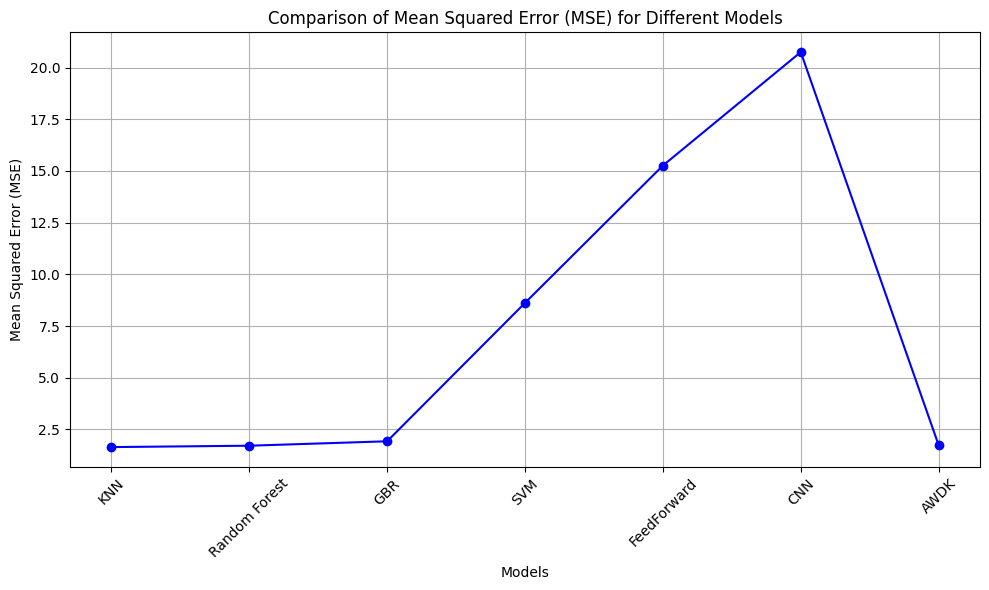

In [ ]:
import matplotlib.pyplot as plt

# List of models
models = ['KNN', 'Random Forest', 'GBR', 'SVM', 'FeedForward', 'CNN', 'AWDK']
# Mean Squared Error values
mse_values = [ mse_knn, mse_rf, mse_gb, mse_svm, mse_ff, mse_cnn, mse_awdk]



# Plotting the line graph
plt.figure(figsize=(10, 6))

# Plot MSE
plt.plot(models, mse_values, marker='o', color='blue')

# Adding labels and title
plt.xlabel('Models')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Comparison of Mean Squared Error (MSE) for Different Models')
plt.xticks(rotation=45)

# Display the plot
plt.grid(True)
plt.tight_layout()
plt.show()


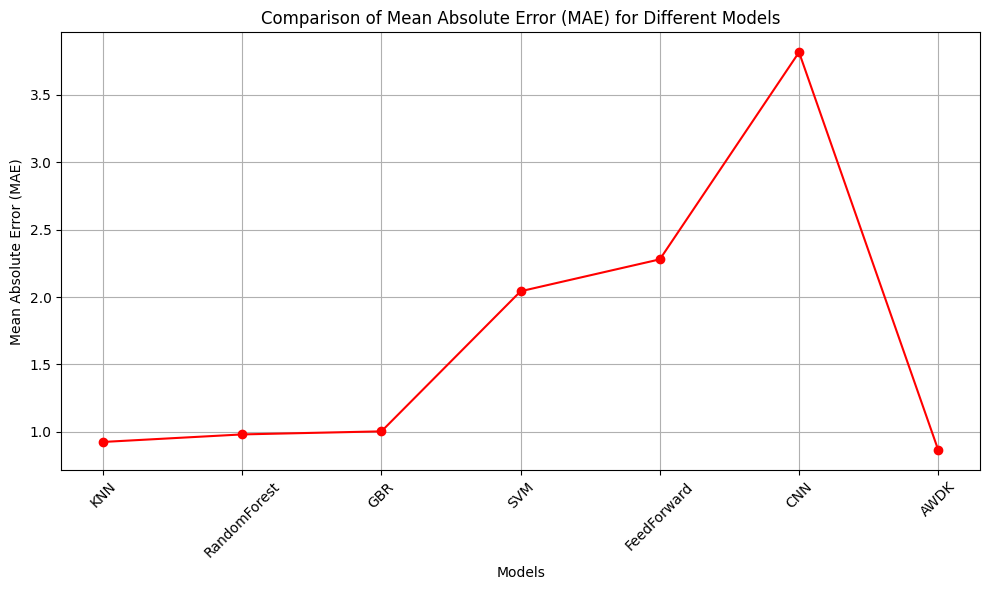

In [ ]:
import matplotlib.pyplot as plt
# List of models
models = ['KNN', 'RandomForest', 'GBR', 'SVM', 'FeedForward', 'CNN', 'AWDK']

# Mean Absolute Error values
mae_values = [mae_knn, mae_rf, mae_gb, mae_svm, mae_ff, mae_cnn, mae_awdk,]

# Find minimum value and its index
min_mae = min(mae_values)
min_index = mae_values.index(min_mae)

# Plotting the line graph
plt.figure(figsize=(10, 6))

# Plot MAE
plt.plot(models, mae_values, marker='o', color='red')

# Adding labels and title
plt.xlabel('Models')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Comparison of Mean Absolute Error (MAE) for Different Models')
plt.xticks(rotation=45)

# Display the plot
plt.grid(True)
plt.tight_layout()
plt.show()


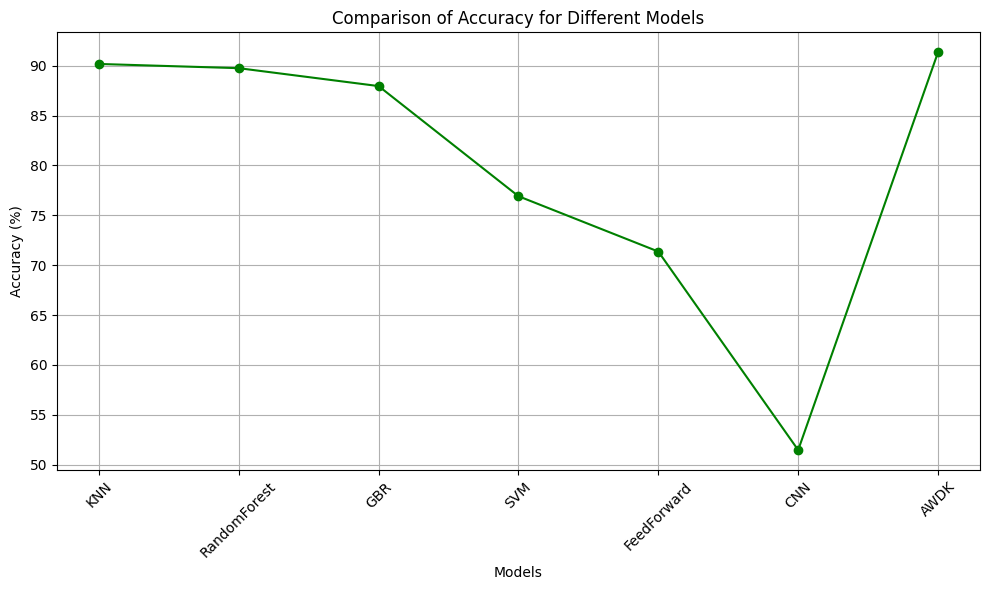

In [ ]:
# Assuming you have Mean Absolute Percentage Error (MAPE) or accuracy values for each model
# Replace these with your actual accuracy values
models = ['KNN', 'RandomForest', 'GBR', 'SVM', 'FeedForward', 'CNN', 'AWDK']
accuracy_values = [accuracy_knn, accuracy_rf, accuracy_gb, accuracy_svm, accuracy_ff, accuracy_cnn, accuracy_awdk]

# Find maximum accuracy and its index
max_accuracy = max(accuracy_values)
max_index = accuracy_values.index(max_accuracy)

# Plotting the line graph for accuracy
plt.figure(figsize=(10, 6))

# Plot accuracy
plt.plot(models, accuracy_values, marker='o', color='green')

# Adding labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Accuracy for Different Models')
plt.xticks(rotation=45)

# Display the plot
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Define the data with accuracy values included
data = {
    'Model': ['KNN', 'Random Forest', 'Gradient Boosting', 'SVM', 'Feed Forward', 'CNN', 'AWDKNN'],
    'Mean Squared Error': [mse_knn, mse_rf, mse_gb, mse_svm, mse_ff, mse_cnn, mse_awdk],
    'Mean Absolute Error': [mae_knn, mae_rf, mae_gb, mae_svm, mae_ff, mae_cnn, mae_awdk],
    'Accuracy (%)': [accuracy_knn, accuracy_rf, accuracy_gb, accuracy_svm, accuracy_ff, accuracy_cnn, accuracy_awdk]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Highlight minimum MSE and MAE for KNN and maximum accuracy
knn_min_mse = df.loc[df['Model'] == 'AWDKNN', 'Mean Squared Error'].values[0]
knn_min_mae = df.loc[df['Model'] == 'AWDKNN', 'Mean Absolute Error'].values[0]
max_accuracy = df['Accuracy (%)'].max()

def highlight_min_max(val):
    if val == knn_min_mse or val == knn_min_mae:
        return 'font-weight: bold; color: red'
    elif val == max_accuracy:
        return 'font-weight: bold; color: green'
    else:
        return ''

# Apply the style function
df_styled = df.style.applymap(highlight_min_max)

# Display the styled DataFrame
df_styled


<ipython-input-25-a664234a9f50>:28: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_styled = df.style.applymap(highlight_min_max)


,Model,Mean Squared Error,Mean Absolute Error,Accuracy (%)
0,KNN,1.643750,0.925000,90.168783
1,Random Forest,1.710810,0.981000,89.745565
2,Gradient Boosting,1.924431,1.003722,87.950824
3,SVM,8.617647,2.043365,76.912403
4,Feed Forward,15.259996,2.280038,71.364604
5,CNN,20.749840,3.817009,51.470873
6,AWDKNN,1.736981,0.864988,91.344071


In [ ]:
# Assuming you already have your trained AWDKNN model as 'awdk_model'

def predict_location_awdk(rss_readings):
    """
    Predict the X, Y coordinates from the given RSS readings using the AWDKNN model.
    """
    # Ensure the input is a numpy array and reshape it as required
    rss_array = np.array(rss_readings).reshape(1, -1)

    # Since you scaled the data before, apply the same scaling transformation
    rss_scaled = scaler_x.transform(rss_array)  # Using the scaler you defined earlier

    # Make the prediction using the trained AWDKNN model
    predicted_coordinates = best_awdknn.predict(rss_scaled)

    # Return the predicted coordinates
    return predicted_coordinates

# Example input (50 RSS readings from the user)
rss_input = input("Enter 50 RSS readings (comma-separated integers): ")
rss_readings = list(map(int, rss_input.split(",")))

# Predict X and Y coordinates
predicted_coordinates = predict_location_awdk(rss_readings)

print("Predicted X and Y coordinates:", predicted_coordinates)


Enter 50 RSS readings (comma-separated integers): -73,-85,-63,-81,-75,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000,-1000
Predicted X and Y coordinates: [[10.98841405  8.98169545]]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
